# 1. Aim

To build and evaluate a Linear Regression model using the California Housing Dataset and understand the complete machine learning workflow including data loading, preprocessing, training, testing, evaluation, and visualization.

# 2. Required Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 3. Load Dataset

In [18]:
# Load California Housing Dataset
data = fetch_california_housing(as_frame=True)

# Create dataframe
df = pd.concat([data.data, data.target.rename("MedHouseVal")], axis=1)

# Display first 5 rows
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


# 4. Exploratory Data Analysis (EDA)
   
**Dataset Information**

In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


**Check Missing Values**

In [20]:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


**Statistical Summary**

In [21]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

**Correlation Matrix**

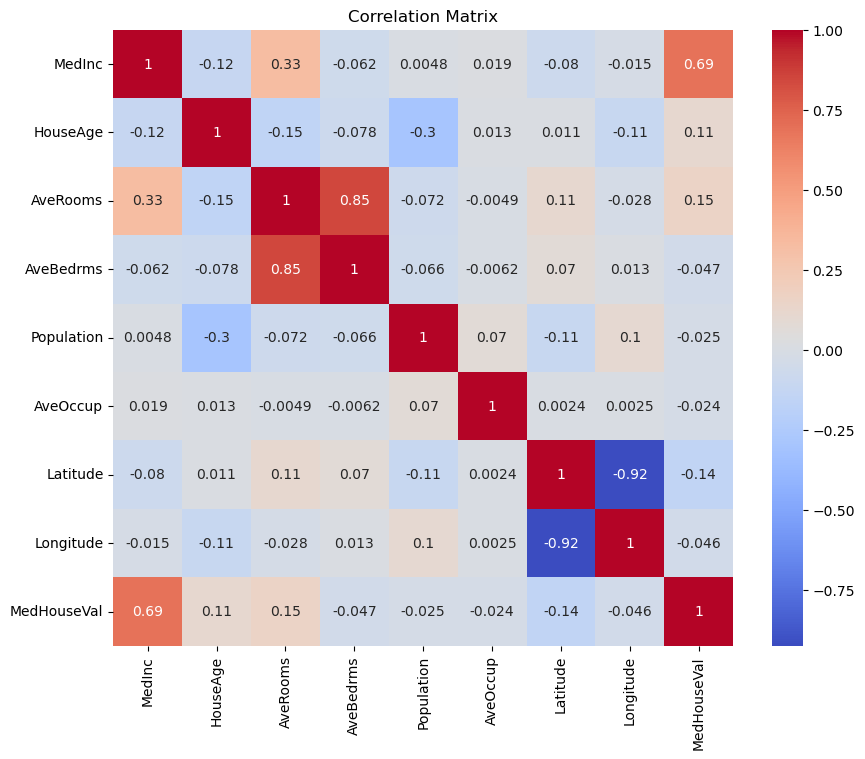

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Distribution of Target Variable**

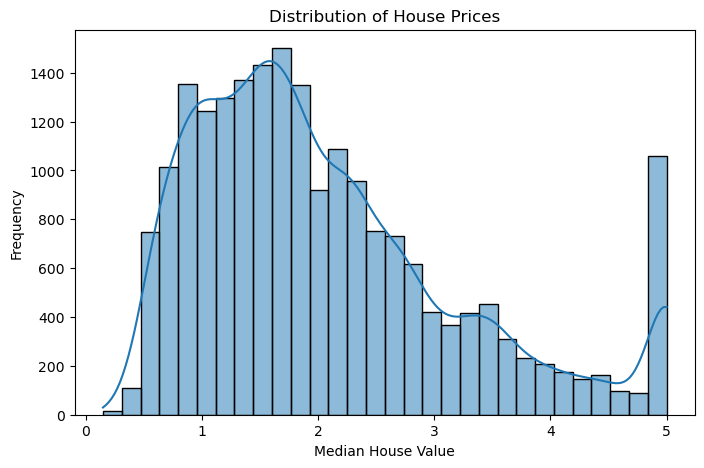

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['MedHouseVal'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

# 5. Feature Selection

In [24]:
# Features
X = df.drop(columns='MedHouseVal')

# Target variable
y = df['MedHouseVal']

# 6. Split Dataset into Training and Testing

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 7. Train Linear Regression Model

In [26]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

# 8. Predict Test Data

In [27]:
# Predictions
y_pred = model.predict(X_test)

 # 9. Evaluate the Model


**Mean Absolute Error (MAE)**

In [28]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.5332001304956563


**Root Mean Squared Error (RMSE)**

In [29]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 0.7455813830127763


**R² Score**

In [30]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.575787706032451


# 10. Visualization

**Actual vs Predicted Values**

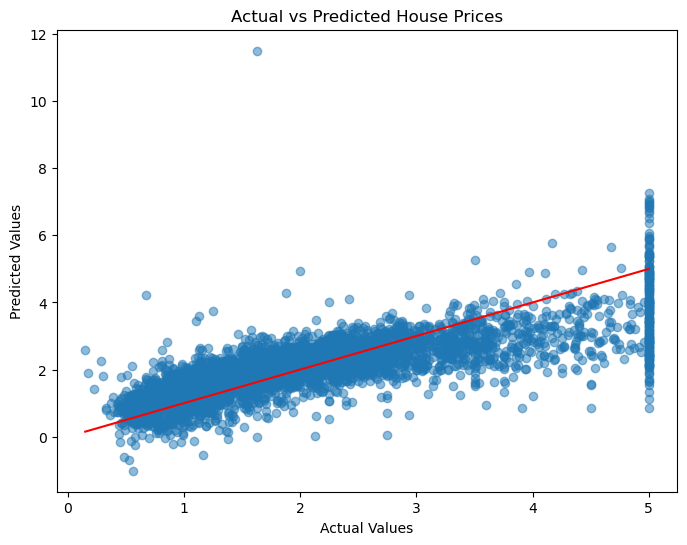

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color='red'
)

plt.show()

**Residual Plot**

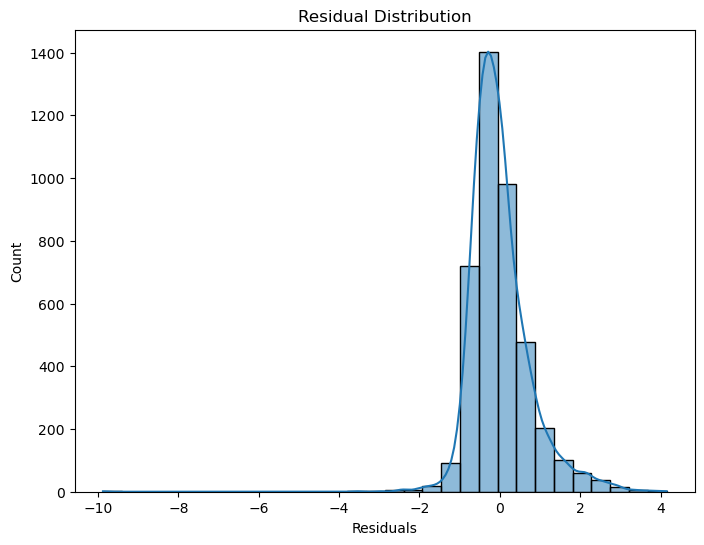

In [32]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Residuals")

plt.show()

# 11. Save the Model (Optional)

In [ ]:
import pickle

with open("linear_regression_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


# 12. Output

**Example Output:**


**MAE:** 0.5332001304956576

**RMSE:** 0.7455813830127765

**R2 Score:** 0.5757877060324507

# 13. Conclusion

The Linear Regression model was successfully trained using the California Housing Dataset. The workflow included data loading, preprocessing, exploratory data analysis, model training, prediction, and evaluation.

The model achieved a reasonable R² score, showing that Linear Regression can capture relationships between housing features and house prices. However, prediction accuracy can still be improved using advanced algorithms such as Random Forest, Decision Tree, or XGBoost.

This task helped in understanding the complete machine learning lifecycle and practical implementation using Python and scikit-learn.